# Library import

In [16]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np


# Add adaface to sys.path so `import net` works without relative imports
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ADAFACE_DIR = os.path.join(REPO_ROOT, 'thirdparty', 'adaface')
if ADAFACE_DIR not in sys.path:
    sys.path.insert(0, ADAFACE_DIR)

import net
from net import Backbone

DATA_ROOT = os.path.join(REPO_ROOT, 'data')
AAF_ROOT = os.path.join(DATA_ROOT, 'All-Age-Faces')
MEGAAGE_ROOT = os.path.join(DATA_ROOT, 'megaage_asian')

# Dataset Load

## Face alignment helper

Uses `face_det_lite` ONNX (same as `model_benchmark.ipynb`) as the detector:
1. Letterbox to 640×480, run ONNX
2. Rotate full frame so the eye line is horizontal (`warpAffine`)
3. Expand bbox by `margin`, crop
4. Letterbox crop to `target_size`
5. Return PIL RGB (unnormalized) — the dataset transform handles normalization

`MegaAgeAsianDataset` images are already pre-cropped (178×218); the transform handles resize.

In [17]:
from dataset.face_pipeline import FaceAlignPipeline

FACE_DET_MODEL_PATH = os.path.join(
    REPO_ROOT, 'models', 'face_det_lite-onnx-w8a8', 'face_det_lite.onnx'
)

face_align = FaceAlignPipeline(
    model_path=FACE_DET_MODEL_PATH,
    target_size=(224, 224),   # match model input; change to (224,224) if using 224 backbone
    margin=0.4,
    score_threshold=0.55,
)

# Quick sanity check on one image
from PIL import Image
test_img = Image.open(os.path.join(AAF_ROOT, 'original images', '00000A02.jpg')).convert('RGB')
result = face_align(test_img)
print('input size:', test_img.size)
print('aligned size:', result.size if result else 'NO FACE DETECTED')

2026-06-16 07:19:01.066400365 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 55 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


input size: (306, 345)
aligned size: (224, 224)


In [18]:
from torchvision import transforms
from torch.utils.data import DataLoader
from dataset.all_age_faces_dataset import AllAgeFacesDataset

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# shuffle once → split → two datasets with guaranteed no overlap
aaf_train, aaf_val = AllAgeFacesDataset.split(
    root=AAF_ROOT,
    train_ratio=0.8,
    seed=42,
    train_kwargs=dict(
        transform=train_transform,
        face_align_fn=face_align,
        low_res_augmentation_prob=0.4, # increase low res augment to adapt real env
        crop_augmentation_prob=0.2,
        photometric_augmentation_prob=0.4, # real env light variance
    ),
    val_kwargs=dict(
        transform=val_transform,
        face_align_fn=face_align,
    ),
)

# num_workers=0: ONNX session is not fork-safe across workers
aaf_train_loader = DataLoader(aaf_train, batch_size=64, shuffle=True,  num_workers=0)
aaf_val_loader   = DataLoader(aaf_val,   batch_size=64, shuffle=False, num_workers=0)

print(f'AAF train: {len(aaf_train)} samples, {len(aaf_train_loader)} batches')
print(f'AAF val:   {len(aaf_val)} samples, {len(aaf_val_loader)} batches')

imgs, labels = next(iter(aaf_train_loader))
print(f'Batch shape: {imgs.shape}, labels: {labels[:8].tolist()}  (0=female, 1=male)')

AAF train: 10657 samples, 167 batches
AAF val:   2665 samples, 42 batches
Batch shape: torch.Size([64, 3, 224, 224]), labels: [0, 0, 1, 0, 1, 1, 0, 1]  (0=female, 1=male)


In [19]:
# from dataset.megaage_asian_dataset import MegaAgeAsianDataset

# # MegaAge images are pre-cropped (178x218) — resize to 112x112 in the transform
# megaage_train_transform = transforms.Compose([
#     transforms.Resize((112, 112)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
# ])
# megaage_val_transform = transforms.Compose([
#     transforms.Resize((112, 112)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
# ])

# mega_train = MegaAgeAsianDataset(
#     root=MEGAAGE_ROOT,
#     split='train',
#     transform=megaage_train_transform,
#     low_res_augmentation_prob=0.2,
#     crop_augmentation_prob=0.2,
#     photometric_augmentation_prob=0.2,
# )
# mega_test = MegaAgeAsianDataset(
#     root=MEGAAGE_ROOT,
#     split='test',
#     transform=megaage_val_transform,
# )

# mega_train_loader = DataLoader(mega_train, batch_size=32, shuffle=True, num_workers=4)
# mega_test_loader  = DataLoader(mega_test,  batch_size=32, shuffle=False, num_workers=4)

# print(f'MegaAge train: {len(mega_train)} samples, {len(mega_train_loader)} batches')
# print(f'MegaAge test:  {len(mega_test)} samples, {len(mega_test_loader)} batches')

# imgs, ages = next(iter(mega_train_loader))
# print(f'Batch shape: {imgs.shape}, ages: {ages[:8].tolist()}')

# Model Load

In [20]:
# model = net.build_model('ir_50')

# # .ckpt is a PyTorch Lightning checkpoint: {'state_dict': {'model.<key>': tensor, ...}}
# # weights_only=False is required because the checkpoint embeds a Lightning callback object
# ckpt = torch.load('../models/adaface_ir50_ms1mv2.ckpt', map_location='cpu', weights_only=False)
# backbone_state = {k[len('model.'):]: v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
# model.load_state_dict(backbone_state)
# model.eval()

# # Print architecture for inspection
# print(model)

# # Save full model (architecture + weights) — loadable with torch.load() without rebuilding the class
# torch.save(model, '../models/adaface_ir50_ms1mv2.pt')
# # Also save state_dict for fine-tuning workflows

# torch.save(model.state_dict(), '../models/adaface_ir50_ms1mv2.pth')
# print("\nSaved: adaface_ir50_ms1mv2.pt  (full model)")
# print("Saved: adaface_ir50_ms1mv2.pth (state_dict only)")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

GENDER_LABELS = ['Female', 'Male']


class GenderClassifier(nn.Module):
    """AdaFace IR-50 body (pretrained, frozen) + gender classification head."""

    def __init__(self, pretrained_backbone):
        super().__init__()
        self.input_layer = pretrained_backbone.input_layer
        self.body = pretrained_backbone.body
        bn_head = pretrained_backbone.output_layer[0]   # BatchNorm2d(512), pretrained
        # 224×224 → 4 stride-2 stages → 14×14, 512 ch.
        # AdaptiveAvgPool2d(1) collapses the 14×14 spatial map to 1×1 before
        # flattening, so the Linear is 512→2 (~1K params) instead of
        # 512*14*14→2 (~200K params) — much less capacity to overfit the
        # frozen features on a ~10k-image dataset.
        self.head = nn.Sequential(
            bn_head,
            nn.Dropout(0.4),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 2),
            nn.BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.body(x)
        return self.head(x)   # [B, 2] raw logits

    def freeze_backbone(self):
        """Freeze pretrained weights (input_layer, body, headbn) AND lock their
        BatchNorm running stats (running_mean/var still drift in train()
        mode even with requires_grad=False unless the submodule is in
        eval())."""
        for module in (self.input_layer, self.body, self.head[0]):
            for p in module.parameters():
                p.requires_grad = False
            module.eval()

    def train(self, mode=True):
        # Keep frozen submodules in eval() even when the rest of the model
        # is switched to train() — overriding nn.Module.train() is the
        # standard way to do this since train()/eval() normally cascades
        # to every submodule.
        super().train(mode)
        if mode and not next(self.input_layer.parameters()).requires_grad:
            self.input_layer.eval()
            self.body.eval()
            self.head[0].eval()
        return self


# Load pretrained backbone; pop output_layer.3 — shape incompatible at 224
backbone = Backbone(input_size=(224, 224), num_layers=50, mode='ir')
state = torch.load('../models/adaface_ir50_ms1mv2.pth', map_location='cpu')
state.pop('output_layer.3.weight', None)
state.pop('output_layer.3.bias', None)
missing, unexpected = backbone.load_state_dict(state, strict=False)
print('pretrained weights loaded — missing:', missing)

model = GenderClassifier(backbone).to(device)
model.freeze_backbone()

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in model.parameters())
print(f'trainable params: {n_trainable:,} / {n_total:,}  (backbone + output BN frozen, head only)')

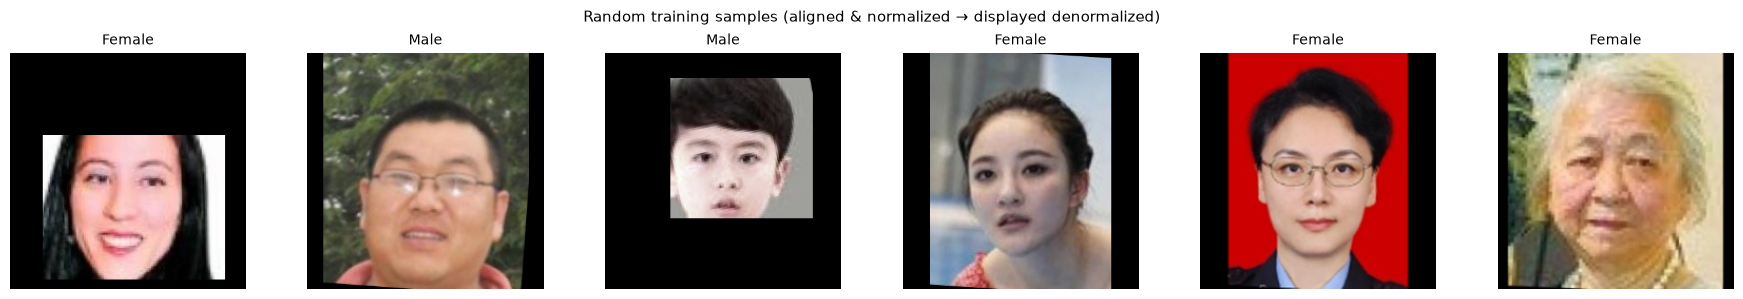

torch.Size([3, 224, 224])


In [9]:
import matplotlib.pyplot as plt
import random as _random

# 6 random aligned samples from training set
chosen_idx = _random.sample(range(len(aaf_train)), 6)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle('Random training samples (aligned & normalized → displayed denormalized)', fontsize=11)
for ax, idx in zip(axes, chosen_idx):
    img_tensor, label = aaf_train[idx]
    # denormalize (mean=0.5, std=0.5 → [0,1]), then BGR→RGB for display
    img_np = img_tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5
    img_np = np.clip(img_np[:, :, ::-1], 0, 1)
    ax.imshow(img_np)
    ax.set_title(GENDER_LABELS[label], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()
print(img_tensor.shape)

# Train

In [ ]:
from tqdm import tqdm   # plain console tqdm (\r-based) — renders reliably without ipywidgets
import torch.nn.functional as F

os.makedirs('../models', exist_ok=True)

criterion  = nn.CrossEntropyLoss()
# only optimize trainable params (head) — backbone is frozen
# weight_decay: L2 penalty on the head's weights to fight the overfitting we saw.
# AdamW applies decoupled weight decay (the more "correct" version vs Adam's L2-in-gradient).
optimizer  = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=1e-4, weight_decay=1e-4)

EPOCHS      = 30   # val metrics plateaued ~epoch 10-20 in the earlier run; no need for 300
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # ── train ────────────────────────────────────────────────────────────────
    model.train()   # GenderClassifier.train() keeps the frozen backbone in eval()
    train_loss = train_correct = train_seen = 0
    train_bar = tqdm(aaf_train_loader, desc=f'{epoch+1}/{EPOCHS}', leave=False)
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_seen    += len(labels)
        train_loss    += loss.item() * len(labels)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_bar.set_postfix(loss=f'{train_loss/train_seen:.4f}',
                              acc=f'{train_correct/train_seen:.4f}')

    train_loss /= len(aaf_train)
    train_acc   = train_correct / len(aaf_train)

    # ── val ──────────────────────────────────────────────────────────────────
    model.eval()
    val_loss = val_correct = val_seen = 0
    val_bar = tqdm(aaf_val_loader, desc=f'{epoch+1}/{EPOCHS}', leave=False)
    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            logits     = model(imgs)
            loss       = criterion(logits, labels)

            val_seen    += len(labels)
            val_loss    += loss.item() * len(labels)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_bar.set_postfix(loss=f'{val_loss/val_seen:.4f}',
                                acc=f'{val_correct/val_seen:.4f}')

    val_loss /= len(aaf_val)
    val_acc   = val_correct / len(aaf_val)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # save last checkpoint every epoch
    torch.save(
        {'epoch': epoch + 1, 'state_dict': model.state_dict(),
         'optimizer': optimizer.state_dict(), 'history': history},
        '../models/gender_last.pth',
    )

    # save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {'epoch': epoch + 1, 'state_dict': model.state_dict(), 'val_acc': val_acc},
            '../models/gender_best.pth',
        )

    # print every epoch — live progress, no nested-bar reliance
    print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
          f'train loss={train_loss:.4f} acc={train_acc:.4f} | '
          f'val loss={val_loss:.4f} acc={val_acc:.4f} | '
          f'best={best_val_acc:.4f}')

print(f'\nDone. Best val acc: {best_val_acc:.4f}')

In [ ]:
# ── Training curves ──────────────────────────────────────────────────────────
os.makedirs('output', exist_ok=True)

epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Cross-Entropy Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('output/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/training_curves.png')

Loaded best model — epoch 54, val_acc=0.9276


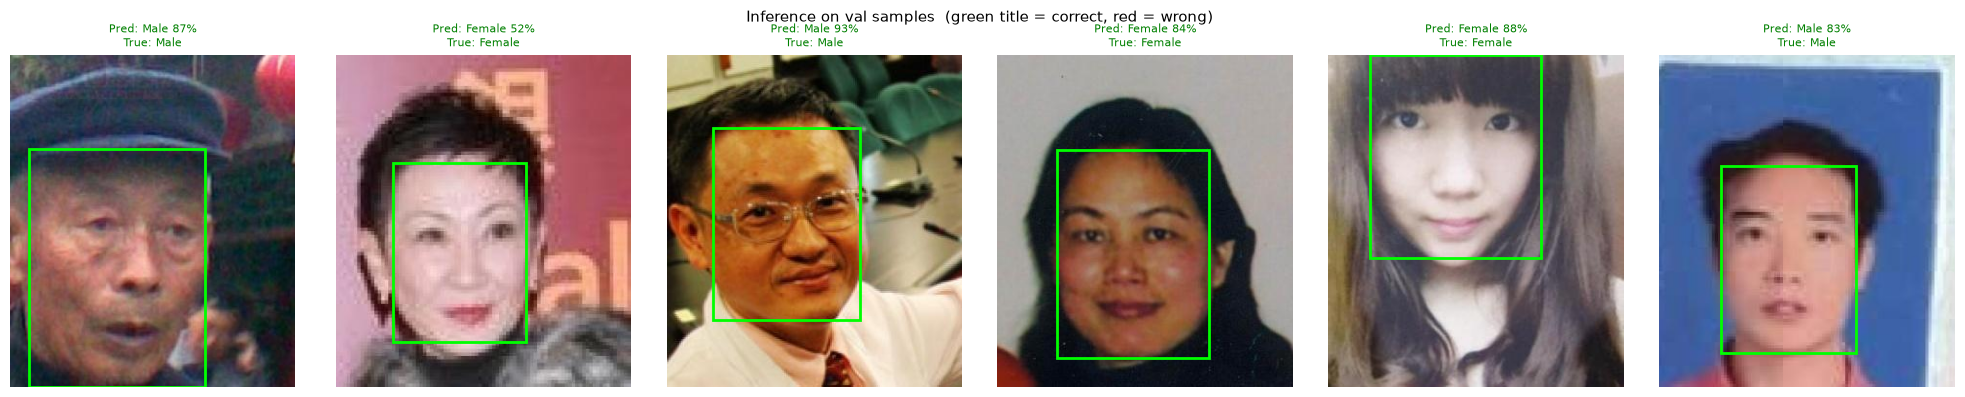

Saved → output/inference_vis.png


In [30]:
import matplotlib.patches as mpatches
import torchvision.transforms.functional as TF
import cv2

# Load best model
ckpt = torch.load('../models/gender_best.pth', map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f"Loaded best model — epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f}")

# ── pick 6 random val samples ─────────────────────────────────────────────────
chosen = _random.sample(aaf_val.samples, 6)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
fig.suptitle('Inference on val samples  (green title = correct, red = wrong)', fontsize=11)

for ax, (img_path, true_label) in zip(axes, chosen):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ── draw face detection bbox on original image ────────────────────────────
    dets = face_align._detect(img_bgr)
    ax.imshow(img_rgb)

    pred_text = 'No detection'
    title_color = 'gray'

    if dets:
        xyxy, score, landmark = dets[0]
        x1, y1, x2, y2 = xyxy
        ax.add_patch(mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none',
        ))

        # ── run model on aligned crop ─────────────────────────────────────────
        aligned = face_align(Image.fromarray(img_rgb))
        if aligned is not None:
            # replicate dataset preprocessing: RGB→BGR PIL → normalize
            aligned_bgr = Image.fromarray(np.asarray(aligned)[:, :, ::-1])
            tensor = TF.normalize(TF.to_tensor(aligned_bgr),
                                  [0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            with torch.no_grad():
                logits = model(tensor.unsqueeze(0).to(device))
                probs  = F.softmax(logits, dim=1)[0]
                pred   = logits.argmax(1).item()
                conf   = probs[pred].item()

            pred_text   = f'{GENDER_LABELS[pred]} {conf:.0%}'
            title_color = 'green' if pred == true_label else 'red'

    ax.set_title(
        f'Pred: {pred_text}\nTrue: {GENDER_LABELS[true_label]}',
        color=title_color, fontsize=8,
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('output/inference_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/inference_vis.png')

# Inference on a custom image path

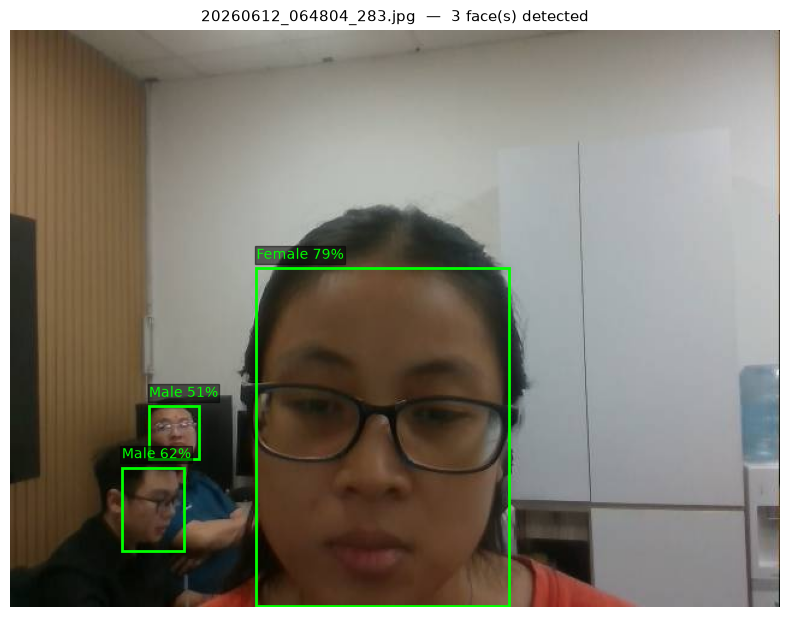

Saved → output/inference_20260612_064804_283.png


In [31]:
def predict_gender_image(img_path, save_dir='output'):
    """Run face detection + gender prediction on an arbitrary image path.
    Draws a bbox + 'Gender conf%' label for every detected face, saves
    the result to save_dir/, and shows it inline.
    """
    img_bgr = cv2.imread(img_path)
    assert img_bgr is not None, f'Could not read image: {img_path}'
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    dets = face_align._detect(img_bgr)   # all faces, not just the best one

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img_rgb)
    ax.set_title(f'{os.path.basename(img_path)}  —  {len(dets)} face(s) detected', fontsize=11)
    ax.axis('off')

    model.eval()
    for xyxy, score, landmark in dets:
        x1, y1, x2, y2 = xyxy
        ax.add_patch(mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none',
        ))

        # crop + align this specific face (face_align() alone only returns the top-1 face)
        crop_bgr = face_align._crop(img_bgr, xyxy, landmark)
        label_text = 'align failed'
        if crop_bgr is not None:
            aligned_rgb = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
            # replicate dataset preprocessing: RGB→BGR PIL → normalize
            aligned_bgr = Image.fromarray(np.asarray(aligned_rgb)[:, :, ::-1])
            tensor = TF.normalize(TF.to_tensor(aligned_bgr),
                                  [0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            with torch.no_grad():
                logits = model(tensor.unsqueeze(0).to(device))
                probs  = F.softmax(logits, dim=1)[0]
                pred   = logits.argmax(1).item()
                conf   = probs[pred].item()
            label_text = f'{GENDER_LABELS[pred]} {conf:.0%}'

        ax.text(x1, max(0, y1 - 8), label_text, color='lime', fontsize=10,
                bbox=dict(facecolor='black', alpha=0.5, pad=1))

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, f"inference_{os.path.splitext(os.path.basename(img_path))[0]}.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')


# Example usage — point this at any image
IMG_PATH = '../data/20260612_064804_283.jpg'
predict_gender_image(IMG_PATH)